# Circuits for Lesson 6 of the Tutorial (Part 2)

The 20 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 6 of the Tutorial (Part 2)*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# On Google Colab the package is not installed yet; install it there.
# A local Jupyter already has it: pip install symbulator[notebook]
import sys
if "google.colab" in sys.modules:
    %pip install -q symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.17'

## 1. Bo2's Example 5.6 (DC, before the switch)

A three-interval problem: one switch opens at t = 0 and another closes at t = 1 s. Find vc(t) and ic(t) for all t; this first interval in DC gives vc = 8 V.

![The circuit of Bo2's Example 5.6 (DC, before the switch)](https://learn.symbulator.com/assets/practice/bo2s-example-5-6-14.jpg)

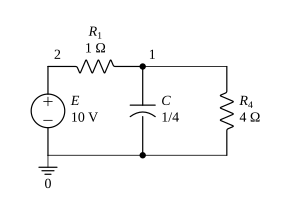

In [3]:
c1 = '''
e,2,0,10
r1,2,1,1
c,1,0,1/4
r4,1,0,4
'''
draw(c1)

In [4]:
r1 = dc(c1)
r1

Result(domain='dc')
  i_c = 0
  i_e = -2
  i_r1 = 2
  i_r4 = 2
  p_c = 0
  p_e = -20
  p_r1 = 4
  p_r4 = 16
  r_e = 5
  v_1 = 8
  v_2 = 10
  v_c = 8
  v_e = 10
  v_r1 = 2
  v_r4 = 8

## 2. Bo2's Example 5.6 (TR, 0 < t <= 1 s)

Second interval: vc and ic decay as e^(-t) from the 8 V initial condition.

![The circuit of Bo2's Example 5.6 (TR, 0 < t <= 1 s)](https://learn.symbulator.com/assets/practice/bo2s-example-5-6-14.jpg)

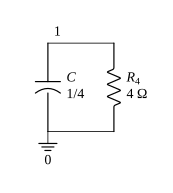

In [5]:
c2 = '''
c,1,0,1/4,8
r4,1,0,4
'''
draw(c2)

In [6]:
r2 = tr(c2)
r2

Result(domain='tr')
  i_c = -2*exp(-t)
  i_r4 = 2*exp(-t)
  v_1 = 8*exp(-t)

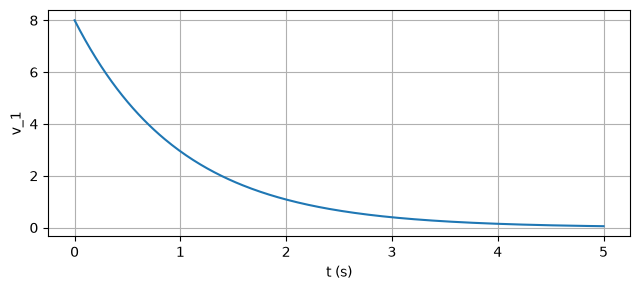

In [7]:
ts, ys = time_samples(c2, 'v_1', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_1'); plt.grid(True); plt.tight_layout()

## 3. Bo2's Example 5.6 (TR, t > 1 s)

Third interval, after the second switch closes. t here counts from the start of this interval, so the chapter writes the answer with (t-1) in it. The initial condition is the previous interval's voltage at t = 1.

![The circuit of Bo2's Example 5.6 (TR, t > 1 s)](https://learn.symbulator.com/assets/practice/bo2s-example-5-6-14.jpg)

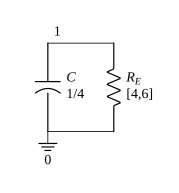

In [8]:
c3 = '''
c,1,0,1/4,2.943
re,1,0,[4,6]
'''
draw(c3)

In [9]:
r3 = tr(c3)
r3.rounded(4)

Result(domain='tr')
  i_c = -1.226*exp(-1.667*t)
  i_re = 1.226*exp(-1.667*t)
  v_1 = 2.943*exp(-1.667*t)

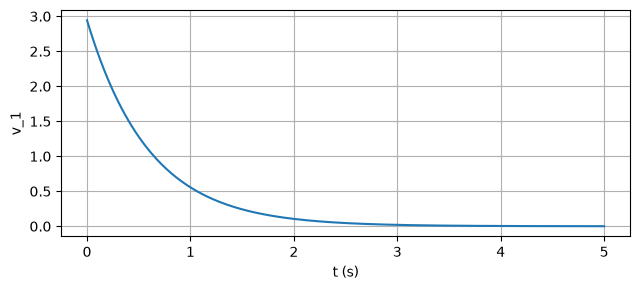

In [10]:
ts, ys = time_samples(c3, 'v_1', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_1'); plt.grid(True); plt.tight_layout()

## 4. Bo2's Drill Exercise 5.6 (DC)

Another problem whose switch moves at a time other than zero — t = 2 s. Find iL(t) and vL(t) for all t; this first interval in DC gives il = 3 A.

![The circuit of Bo2's Drill Exercise 5.6 (DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-6-17.jpg)

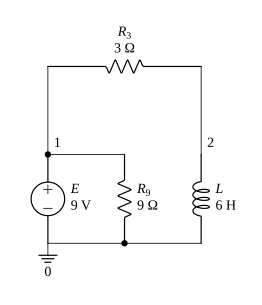

In [11]:
c4 = '''
e,1,0,9
r9,1,0,9
r3,1,2,3
l,2,0,6
'''
draw(c4)

In [12]:
r4 = dc(c4)
r4

Result(domain='dc')
  i_e = -4
  i_l = 3
  i_r3 = 3
  i_r9 = 1
  p_e = -36
  p_l = 0
  p_r3 = 27
  p_r9 = 9
  r_e = 9/4
  v_1 = 9
  v_2 = 0
  v_e = 9
  v_l = 0
  v_r3 = 9
  v_r9 = 9

## 5. Bo2's Drill Exercise 5.6 (TR, 0 < t <= 2 s)

Second interval: il and vl decay as e^(-2t).

![The circuit of Bo2's Drill Exercise 5.6 (TR, 0 < t <= 2 s)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-6-17.jpg)

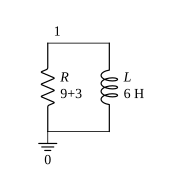

In [13]:
c5 = '''
r,1,0,9+3
l,1,0,6,3
'''
draw(c5)

In [14]:
r5 = tr(c5)
r5

Result(domain='tr')
  i_l = 3*exp(-2*t)
  i_r = -3*exp(-2*t)
  v_1 = -36*exp(-2*t)

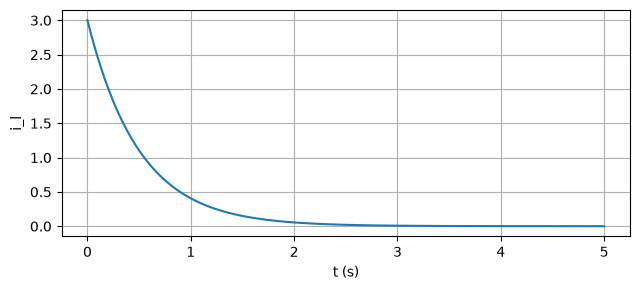

In [15]:
ts, ys = time_samples(c5, 'i_l', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 6. Bo2's Drill Exercise 5.6 (TR, t > 2 s)

Third interval, starting from the 0.055 A the second interval left at t = 2 s; the chapter writes the answers with (t-2) in them.

![The circuit of Bo2's Drill Exercise 5.6 (TR, t > 2 s)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-6-17.jpg)

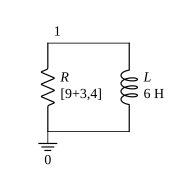

In [16]:
c6 = '''
r,1,0,[9+3,4]
l,1,0,6,.055
'''
draw(c6)

In [17]:
r6 = tr(c6)
r6.rounded(3)

Result(domain='tr')
  i_l = 0.055*exp(-0.5*t)
  i_r = -0.055*exp(-0.5*t)
  v_1 = -0.165*exp(-0.5*t)

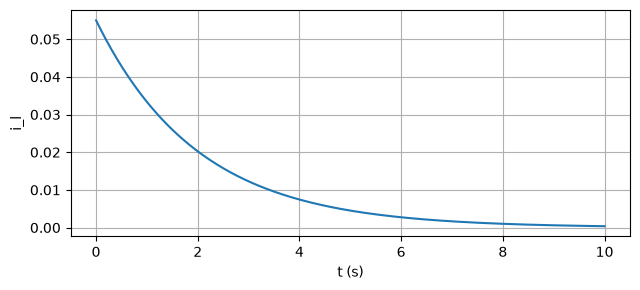

In [18]:
ts, ys = time_samples(c6, 'i_l', 10, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 7. Bo2's Figure 5.19 (step source, RC)

In this problem, we use a step source, V*u(t), for the first time. Find iR, vR, iC and vC for the series RC circuit, symbolically.

![The circuit of Bo2's Figure 5.19 (step source, RC)](https://learn.symbulator.com/assets/practice/bo2s-figure-5-19-18.jpg)

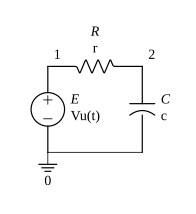

In [19]:
c7 = '''
e,1,0,V*u(t)
r,1,2,r
c,2,0,c,0
'''
draw(c7)

In [20]:
r7 = tr(c7)
r7

Result(domain='tr')
  i_c = V*exp(-t/(c*r))/r
  i_e = -V*exp(-t/(c*r))/r
  i_r = V*exp(-t/(c*r))/r
  v_1 = V
  v_2 = V - V*exp(-t/(c*r))

## 8. Bo2's Figure 5.24 (step source, RL)

The RL twin of the previous entry, with the same step source: find iR, vR, iL and vL.

![The circuit of Bo2's Figure 5.24 (step source, RL)](https://learn.symbulator.com/assets/practice/bo2s-figure-5-24-19.jpg)

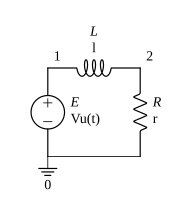

In [21]:
c8 = '''
e,1,0,V*u(t)
l,1,2,l,0
r,2,0,r
'''
draw(c8)

In [22]:
r8 = tr(c8)
r8

Result(domain='tr')
  i_e = -V/r + V*exp(-r*t/l)/r
  i_l = V/r - V*exp(-r*t/l)/r
  i_r = V/r - V*exp(-r*t/l)/r
  v_1 = V
  v_2 = V - V*exp(-r*t/l)

## 9. Bo2's Drill Exercise 5.7 (numerical step)

A numerical step source: a plain 12 is enough, no u(t) needed. Find il, vl and v.

![The circuit of Bo2's Drill Exercise 5.7 (numerical step)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-7-20.jpg)

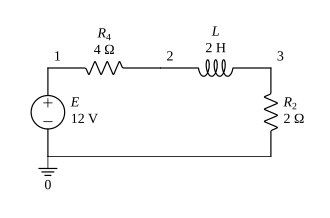

In [23]:
c9 = '''
e,1,0,12
r4,1,2,4
l,2,3,2,0
r2,3,0,2
'''
draw(c9)

In [24]:
r9 = tr(c9)
r9

Result(domain='tr')
  i_e = -2 + 2*exp(-3*t)
  i_l = 2 - 2*exp(-3*t)
  i_r2 = 2 - 2*exp(-3*t)
  i_r4 = 2 - 2*exp(-3*t)
  v_1 = 12
  v_2 = 4 + 8*exp(-3*t)
  v_3 = 4 - 4*exp(-3*t)

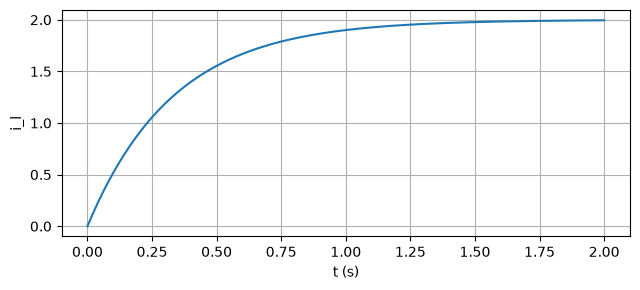

In [25]:
ts, ys = time_samples(c9, 'i_l', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 10. Bo2's Figure 5.26 (step current source)

A step current source, i*u(t): find iC, iR and v — read ic, ir and v1.

![The circuit of Bo2's Figure 5.26 (step current source)](https://learn.symbulator.com/assets/practice/bo2s-figure-5-26-21.jpg)

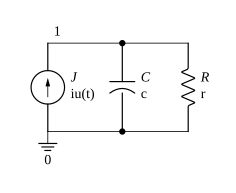

In [26]:
c10 = '''
j,0,1,i*u(t)
c,1,0,c,0
r,1,0,r
'''
draw(c10)

In [27]:
r10 = tr(c10)
r10

Result(domain='tr')
  i_c = i*exp(-t/(c*r))
  i_j = i
  i_r = i - i*exp(-t/(c*r))
  v_1 = i*r - i*r*exp(-t/(c*r))

## 11. Bo2's Example 5.7 (Op Amp, step)

An op amp with a unit-step input: find vc, ic and vo. This circuit returns, altered, in several later entries.

![The circuit of Bo2's Example 5.7 (Op Amp, step)](https://learn.symbulator.com/assets/practice/bo2s-example-5-7-op-amp-22.jpg)

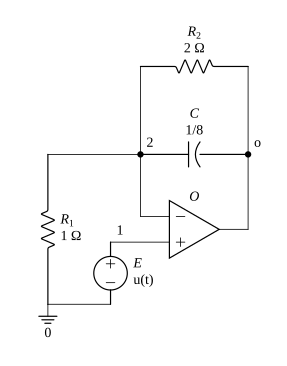

In [28]:
c11 = '''
e,1,0,u(t)
o,1,2,o
c,2,o,1/8,0
r2,2,o,2
r1,2,0,1
'''
draw(c11)

In [29]:
r11 = tr(c11)
r11

Result(domain='tr')
  i_c = -exp(-4*t)
  i_e = 0
  i_o = 1
  i_r1 = 1
  i_r2 = -1 + exp(-4*t)
  v_1 = 1
  v_2 = 1
  v_o = 3 - 2*exp(-4*t)

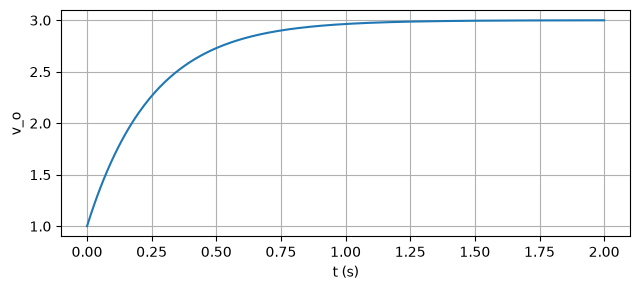

In [30]:
ts, ys = time_samples(c11, 'v_o', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()

## 12. Bo2's Drill Exercise 5.8 (Op Amp, step)

Find vc, ic and vo for the companion op-amp circuit, also with a unit-step input.

![The circuit of Bo2's Drill Exercise 5.8 (Op Amp, step)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-8-op-amp-23.jpg)

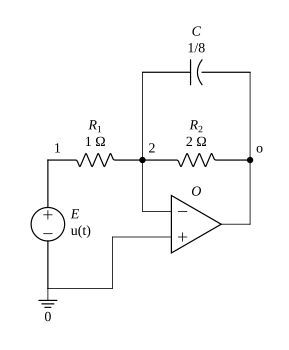

In [31]:
c12 = '''
e,1,0,u(t)
r1,1,2,1
r2,2,o,2
c,2,o,1/8,0
o,0,2,o
'''
draw(c12)

In [32]:
r12 = tr(c12)
r12

Result(domain='tr')
  i_c = exp(-4*t)
  i_e = -1
  i_o = -1
  i_r1 = 1
  i_r2 = 1 - exp(-4*t)
  v_1 = 1
  v_2 = 0
  v_o = -2 + 2*exp(-4*t)

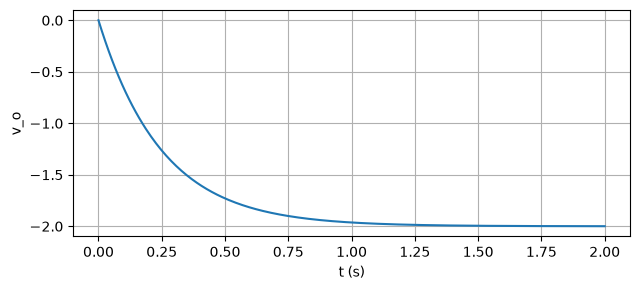

In [33]:
ts, ys = time_samples(c12, 'v_o', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()

## 13. Bo2's p249 F5.28 (TR, first interval)

A source of V*u(t) - V*u(t-to), taken in two intervals. First interval: find vc, the charging curve.

![The circuit of Bo2's p249 F5.28 (TR, first interval)](https://learn.symbulator.com/assets/practice/bo2s-p249-f5-28-24.jpg)

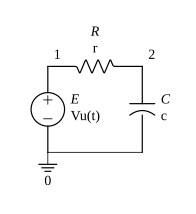

In [34]:
c13 = '''
e,1,0,V*u(t)
r,1,2,r
c,2,0,c,0
'''
draw(c13)

In [35]:
r13 = tr(c13)
r13

Result(domain='tr')
  i_c = V*exp(-t/(c*r))/r
  i_e = -V*exp(-t/(c*r))/r
  i_r = V*exp(-t/(c*r))/r
  v_1 = V
  v_2 = V - V*exp(-t/(c*r))

## 14. Bo2's p249 F5.28 (TR, second interval)

Second interval, from t = to: the source is a short now, and the capacitor's initial condition is the first interval's vc at to, written out in full.

![The circuit of Bo2's p249 F5.28 (TR, second interval)](https://learn.symbulator.com/assets/practice/bo2s-p249-f5-28-24.jpg)

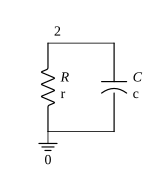

In [36]:
c14 = '''
r,0,2,r
c,2,0,c,v-e^(-to/(c*r))*v
'''
draw(c14)

In [37]:
r14 = tr(c14)
r14

Result(domain='tr')
  i_c = v*(1 - exp(to/(c*r)))*exp(-(t + to)/(c*r))/r
  i_r = v*(1 - exp(to/(c*r)))*exp(-(t + to)/(c*r))/r
  v_2 = v*(exp(to/(c*r)) - 1)*exp(-(t + to)/(c*r))

## 15. Bo2's Drill Exercise 5.9 (TR, first interval)

The RL version of the two-step-source problem. First interval: find il.

![The circuit of Bo2's Drill Exercise 5.9 (TR, first interval)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-9-25.jpg)

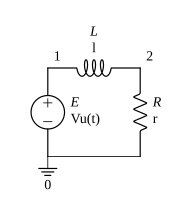

In [38]:
c15 = '''
e,1,0,V*u(t)
l,1,2,l,0
r,2,0,r
'''
draw(c15)

In [39]:
r15 = tr(c15)
r15

Result(domain='tr')
  i_e = -V/r + V*exp(-r*t/l)/r
  i_l = V/r - V*exp(-r*t/l)/r
  i_r = V/r - V*exp(-r*t/l)/r
  v_1 = V
  v_2 = V - V*exp(-r*t/l)

## 16. Bo2's Drill Exercise 5.9 (TR, second interval)

Second interval: the source is gone and the inductor starts from its t = to current; replace t with t-to to put the answer on the first interval's clock.

![The circuit of Bo2's Drill Exercise 5.9 (TR, second interval)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-5-9-25.jpg)

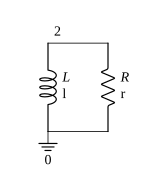

In [40]:
c16 = '''
l,0,2,l,v/r-e^(-to*r/l)*v/r
r,2,0,r
'''
draw(c16)

In [41]:
r16 = tr(c16)
r16

Result(domain='tr')
  i_l = v*(exp(r*to/l) - 1)*exp(-r*(t + to)/l)/r
  i_r = v*(exp(r*to/l) - 1)*exp(-r*(t + to)/l)/r
  v_2 = v*(exp(r*to/l) - 1)*exp(-r*(t + to)/l)

## 17. Bo2's Figure 5.36 (DC, first interval)

A dependent source rides along this time. First interval in DC, with the source at 2 V: vc is 2 V.

![The circuit of Bo2's Figure 5.36 (DC, first interval)](https://learn.symbulator.com/assets/practice/bo2s-figure-5-36-26.jpg)

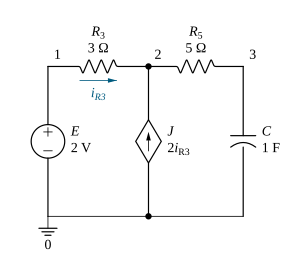

In [42]:
c17 = '''
e,1,0,2
r3,1,2,3
r5,2,3,5
c,3,0,1
j,0,2,2*ir3
'''
draw(c17)

In [43]:
r17 = dc(c17)
r17

Result(domain='dc')
  i_c = 0
  i_e = 0
  i_j = 0
  i_r3 = 0
  i_r5 = 0
  p_c = 0
  p_e = 0
  p_j = 0
  p_r3 = 0
  p_r5 = 0
  r_e = oo
  r_j = oo
  v_1 = 2
  v_2 = 2
  v_3 = 2
  v_c = 2
  v_e = 2
  v_j = -2
  v_r3 = 0
  v_r5 = 0

## 18. Bo2's Figure 5.36 (TR, second interval)

Second interval in TR, with the source at -4 V: vc comes back 6e^(-t/6) - 4.

![The circuit of Bo2's Figure 5.36 (TR, second interval)](https://learn.symbulator.com/assets/practice/bo2s-figure-5-36-26.jpg)

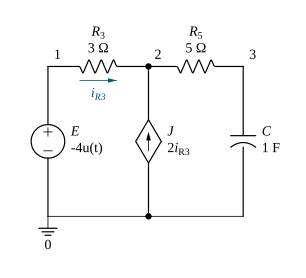

In [44]:
c18 = '''
e,1,0,-4*u(t)
r3,1,2,3
r5,2,3,5
c,3,0,1,2
j,0,2,2*ir3
'''
draw(c18)

In [45]:
r18 = tr(c18)
r18

Result(domain='tr')
  i_c = -exp(-t/6)
  i_e = exp(-t/6)/3
  i_j = -2*exp(-t/6)/3
  i_r3 = -exp(-t/6)/3
  i_r5 = -exp(-t/6)
  v_1 = -4
  v_2 = -4 + exp(-t/6)
  v_3 = -4 + 6*exp(-t/6)

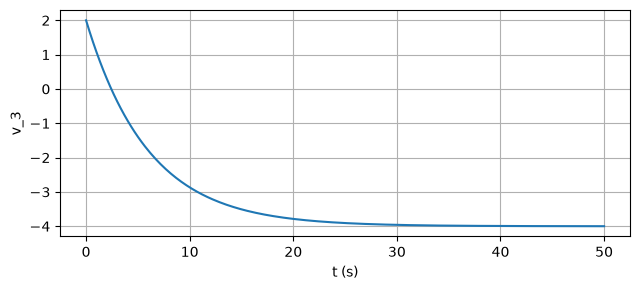

In [46]:
ts, ys = time_samples(c18, 'v_3', 50, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_3'); plt.grid(True); plt.tight_layout()

## 19. Bo2's Drill Exercise 5.11 (DC)

Example 5.7's circuit with a 1/4 F capacitor and the source at 1 V for t < 0: this DC interval gives vc = -2 V.

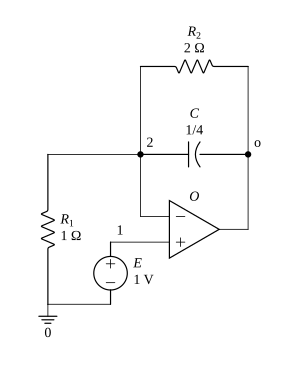

In [47]:
c19 = '''
e,1,0,1
o,1,2,o
c,2,o,1/4
r2,2,o,2
r1,2,0,1
'''
draw(c19)

In [48]:
r19 = dc(c19)
r19

Result(domain='dc')
  i_c = 0
  i_e = 0
  i_o = 1
  i_r1 = 1
  i_r2 = -1
  p_c = 0
  p_e = 0
  p_o = -3
  p_r1 = 1
  p_r2 = 2
  r_e = oo
  v_1 = 1
  v_2 = 1
  v_c = -2
  v_e = 1
  v_o = 3
  v_r1 = 1
  v_r2 = -2

## 20. Bo2's Drill Exercise 5.11 (TR)

Second interval, source at 3 V: vc comes back 4e^(-2t) - 6. The chapter introduces the `only` tool here, and this entry uses it: only vc is transformed back into time. On a circuit this small the saving is slight; on a heavy one it is the difference between fifteen seconds and ten.

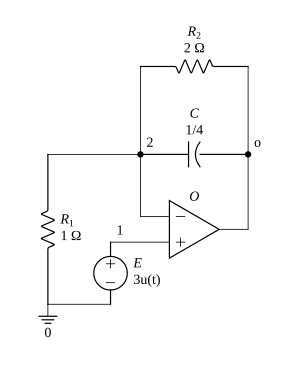

In [49]:
c20 = '''
e,1,0,3*u(t)
o,1,2,o
c,2,o,1/4,-2
r2,2,o,2
r1,2,0,1
'''
draw(c20)

In [50]:
r20 = tr(c20, variables=['v_2', 'v_o'])
r20

Result(domain='tr')
  v_2 = 3
  v_o = 9 - 4*exp(-2*t)

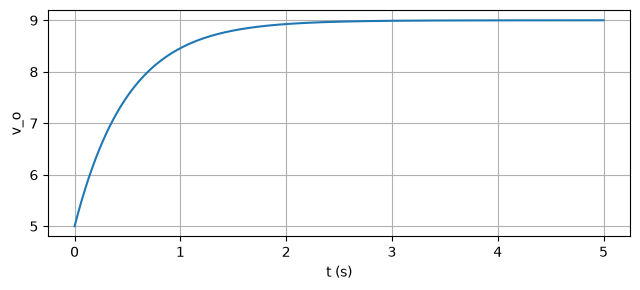

In [51]:
ts, ys = time_samples(c20, 'v_o', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()